# Tarea Clase 4

##  Tarea 1
Une las bases anuales de homicidios: homicidios_2017.csv, homicidios_2018.csv, homicidios_2019.csv, homicidios_2020.csv, homicidios_2021.csv, homicidios_2022.csv, homicidios_2023.csv. Realiza:
- Lee cada archivo usando pd.read_csv().
- A cada base agrega una columna llamada "Año".
- Une todas las bases en un solo DataFrame llamado df_homicidios.
- Crea una columna llamada "Total" (Total = Mujeres + Hombres + No_esp)
- Preguntas para responder:
  - ¿Cuántos registros tiene la base completa?
  - ¿Cuántos homicidios se registraron en total entre 2017 y 2023?
  - ¿Qué año tuvo el mayor número total de homicidios?
  - ¿Qué año tuvo el menor número total de homicidios?
  

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ruta2017="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2017.csv"
ruta2018="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2018.csv"
ruta2019="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2019.csv"
ruta2020="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2020.csv"
ruta2021="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2021.csv"
ruta2022="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2022.csv"
ruta2023="https://raw.githubusercontent.com/jamc88/min-curso/refs/heads/main/Datos/homicidios_2023.csv"


In [38]:
archivos = [
(ruta2017, 2017),
(ruta2018, 2018),
(ruta2019, 2019),
(ruta2020, 2020),
(ruta2021, 2021),
(ruta2022, 2022),
(ruta2023, 2023)
]

bases=[]
for archivo,año in archivos:
    df=pd.read_csv(archivo) # Lee cada csv
    df["Año"]=año           # A cada df le agrega la columna "Año"
    bases.append(df)        # Agregar a bases la base actual

#print(bases)   # bases es una lista de dataframes

# Para unir varios DataFrames pd.concat. Para reiniciar índice usar ignore_index=True
df_homicidios=pd.concat(bases,ignore_index=True)

df_homicidios



,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Año
0,Aguascalientes,AG,Noreste,8,76,0,2017
1,Baja California,BC,Noroeste,205,1955,9,2017
2,Baja California Sur,BS,Noroeste,77,673,1,2017
3,Campeche,CM,Sureste,6,72,0,2017
4,Coahuila de Zaragoza,CO,Noreste,41,234,0,2017
...,...,...,...,...,...,...,...
219,Tamaulipas,TM,Noreste,56,476,28,2023
220,Tlaxcala,TL,Centro-Sur,17,122,0,2023
221,Veracruz,VE,Sureste,89,698,2,2023
222,Yucatan,YU,Sureste,13,39,0,2023


In [39]:
# Crea una columna llamada "Total" (Total = Mujeres + Hombres + No_esp)
df_homicidios["Total"]=df_homicidios["Mujeres"]+df_homicidios["Hombres"]+df_homicidios["No_esp"]
df_homicidios.head(3)

,Estado,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Año,Total
0,Aguascalientes,AG,Noreste,8,76,0,2017,84
1,Baja California,BC,Noroeste,205,1955,9,2017,2169
2,Baja California Sur,BS,Noroeste,77,673,1,2017,751


### ¿Cuántos registros tiene la base completa?
La base completa tiene 224 registros contemplando de 2017 a 2023.

In [40]:
df_homicidios.shape
print("Se tienen ", df_homicidios.shape[0]," filas con ",df_homicidios.shape[1]," columnas" )

Se tienen  224  filas con  8  columnas


### ¿Cuántos homicidios se registraron en total entre 2017 y 2023?


In [41]:
print("El número de homicidios totales entre 2017 y 2023 es: ",df_homicidios["Total"].sum())

El número de homicidios totales entre 2017 y 2023 es:  241476


### ¿Qué año tuvo el mayor número total de homicidios?

El año con mayor número de homicidios fue 2018 con 36685

In [42]:
# Haciendo índices los años
hom=df_homicidios.set_index("Año")

#df2017=hom.loc[2017]  #Tomar las filas que tengan etiqueta año y guardar en un dataframe
#df2017["Total"].sum() # Calcular la suma de la columna "Total"

#hom.loc[2017]["Total"].sum()  # Resumiendo los dos pasos anteriores en uno


for i in range(2017,2024):
    homicidios_año=hom.loc[i]["Total"].sum()
    print("Los homicidios en el año ",i," son: ",homicidios_año)



Los homicidios en el año  2017  son:  32079
Los homicidios en el año  2018  son:  36685
Los homicidios en el año  2019  son:  36661
Los homicidios en el año  2020  son:  36773
Los homicidios en el año  2021  son:  35700
Los homicidios en el año  2022  son:  32223
Los homicidios en el año  2023  son:  31355


### ¿Qué año tuvo el menor número total de homicidios?
El año con mayor número de homicidios fue 2023 con 31355

## Tarea 2
Usando la base unida df_homicidios, realiza lo siguiente:
- Calcula el total de homicidios por año.
- Calcula el total de homicidios por estado entre 2017 y 2023.
- Calcula el total de homicidios por región entre 2017 y 2023.
- Identifica los 5 estados con mayor número acumulado de homicidios.
- Grafica la evolución nacional de homicidios por año.
- Preguntas para responder:
  - ¿La tendencia nacional aumenta, disminuye o se mantiene relativamente estable?
  - ¿Cuáles son los 5 estados con más homicidios acumulados?
  - ¿Qué región concentra el mayor número de homicidios?
  - ¿Qué región concentra el menor número de homicidios?
  - ¿Qué conclusiones generales puedes obtener de la gráfica?

### Calcula el total de homicidios por año

In [43]:
# Calcular el total de  homicidios por año

###Tomar las filas que tengan etiqueta año y guardar en un dataframe
#print(df_homicidios.head(3))
#print(df_homicidios.columns)
#print(df_homicidios["Año"].dtype)

hom=df_homicidios.set_index("Año")  # indexa por año. los años son de tipo int

# Lo que hace. Filtrar: filtrado = hom.loc[i]  . Columna total: columna_total = filtrado["Total"] . Sumar: homicidios_año = columna_total.sum()
# Se puede hacer sin for: hom.groupby("Año")["Total"].sum() . La salida es una Serie con el total de homicidios por año

for i in range(2017,2024):
    homicidios_año=hom.loc[i]["Total"].sum()
    print("Los homicidios en el año ",i," son: ",homicidios_año)


Los homicidios en el año  2017  son:  32079
Los homicidios en el año  2018  son:  36685
Los homicidios en el año  2019  son:  36661
Los homicidios en el año  2020  son:  36773
Los homicidios en el año  2021  son:  35700
Los homicidios en el año  2022  son:  32223
Los homicidios en el año  2023  son:  31355


### Calcula el total de homicidios por estado entre 2017 y 2023.

In [63]:
# Calcula el total de homicidios por estado entre 2017 y 2023.

estados=df_homicidios.set_index("Estado")
#print(estados)
estados.loc[" Aguascalientes"]

,Abreviatura,Regiones,Mujeres,Hombres,No_esp,Año,Total
Estado,,,,,,,
Aguascalientes,AG,Noreste,8,76,0,2017,84
Aguascalientes,AG,Noreste,9,73,0,2018,82
Aguascalientes,AG,Noreste,11,108,1,2019,120
Aguascalientes,AG,Noreste,7,86,0,2020,93
Aguascalientes,AG,Noreste,13,90,0,2021,103
Aguascalientes,AG,Noreste,13,73,1,2022,87
Aguascalientes,AG,Noreste,14,90,1,2023,105


In [46]:
estados.loc[" Aguascalientes"]["Total"].sum()
print("El número total de homicidios en Aguascalientes de 2017-2023 es: ",estados.loc[" Aguascalientes"]["Total"].sum())

El número total de homicidios en Aguascalientes de 2017-2023 es:  674


In [68]:
# Resumiendo en pocas lineas de código
lista=[]
for i in df_homicidios["Estado"]:
    if i in lista:
        continue
    else:
        lista.append(i)
#print(lista)

for i in lista:
    homicidios_estado=estados.loc[i]["Total"].sum()
    print("Los homicidios de",i," de 2017 a 2023 son: ",homicidios_estado)


# Hay formas de hacerlo de forma sencilla usando: resumen = df_homicidios.groupby("Estado")["Total"].sum()
#    Esto devuelve directamente una Serie con el total de homicidios por estado entre 2017 y 2023
resumen_estado = df_homicidios.groupby("Estado")["Total"].sum()
resumen_estado

Los homicidios de  Aguascalientes  de 2017 a 2023 son:  674
Los homicidios de  Baja California  de 2017 a 2023 son:  19365
Los homicidios de  Baja California Sur  de 2017 a 2023 son:  1347
Los homicidios de  Campeche  de 2017 a 2023 son:  637
Los homicidios de  Coahuila de Zaragoza  de 2017 a 2023 son:  1523
Los homicidios de  Colima  de 2017 a 2023 son:  5461
Los homicidios de  Chiapas  de 2017 a 2023 son:  4102
Los homicidios de  Chihuahua  de 2017 a 2023 son:  18541
Los homicidios de  CDMX  de 2017 a 2023 son:  7992
Los homicidios de  Durango  de 2017 a 2023 son:  1084
Los homicidios de  Guanajuato  de 2017 a 2023 son:  27639
Los homicidios de  Guerrero  de 2017 a 2023 son:  13019
Los homicidios de  Hidalgo  de 2017 a 2023 son:  2559
Los homicidios de  Jalisco  de 2017 a 2023 son:  15151
Los homicidios de  Mexico  de 2017 a 2023 son:  21852
Los homicidios de  Michoacan  de 2017 a 2023 son:  15509
Los homicidios de  Morelos  de 2017 a 2023 son:  7423
Los homicidios de  Nayarit  de 20

Estado
Aguascalientes            674
Baja California         19365
Baja California Sur      1347
CDMX                     7992
Campeche                  637
Chiapas                  4102
Chihuahua               18541
Coahuila de Zaragoza     1523
Colima                   5461
Durango                  1084
Guanajuato              27639
Guerrero                13019
Hidalgo                  2559
Jalisco                 15151
Mexico                  21852
Michoacan               15509
Morelos                  7423
Nayarit                  1829
Nuevo Leon               7284
Oaxaca                   6542
Puebla                   7537
Queretaro                1543
Quintana Roo             4688
San Luis Potosi          4497
Sinaloa                  6695
Sonora                   9958
Tabasco                  3355
Tamaulipas               6090
Tlaxcala                 1072
Veracruz                 8417
Yucatan                   390
Zacatecas                7701
Name: Total, dtype: int64

### Calcula el total de homicidios por región entre 2017 y 2023.

In [117]:
lista=[]
for i in df_homicidios["Regiones"]:
    if i in lista:
        continue
    else:
        lista.append(i)
print(lista)

regiones=df_homicidios.set_index("Regiones") # Indexando por regiones
#print(regiones)

for i in lista:
    hom_region=regiones.loc[i]["Total"].sum()
    print("Los homicidios en la región ",i," de 2017 a 2023 son: ",hom_region)


# Usando groupby alternativamente
resumen_regiones=df_homicidios.groupby("Regiones")["Total"].sum()
resumen_regiones

['Noreste', 'Noroeste', 'Sureste', 'Occidente', 'Centro-Sur']
Los homicidios en la región  Noreste  de 2017 a 2023 son:  56951
Los homicidios en la región  Noroeste  de 2017 a 2023 son:  73970
Los homicidios en la región  Sureste  de 2017 a 2023 son:  28131
Los homicidios en la región  Occidente  de 2017 a 2023 son:  45381
Los homicidios en la región  Centro-Sur  de 2017 a 2023 son:  37043


Regiones
Centro-Sur    37043
Noreste       56951
Noroeste      73970
Occidente     45381
Sureste       28131
Name: Total, dtype: int64

### Identifica los 5 estados con mayor número acumulado de homicidios.

In [86]:
type(resumen_estado)
resumen_estado.to_frame().sort_values("Total",ascending=False).head(5)
#resumen_estado.sort_values("Total",ascending=False)

,Total
Estado,
Guanajuato,27639
Mexico,21852
Baja California,19365
Chihuahua,18541
Michoacan,15509


### Grafica la evolución nacional de homicidios por año.

In [106]:
resumen_año = df_homicidios.groupby("Año")["Total"].sum()
ev=resumen_año.to_frame()
ev

,Total
Año,
2017,32079
2018,36685
2019,36661
2020,36773
2021,35700
2022,32223
2023,31355


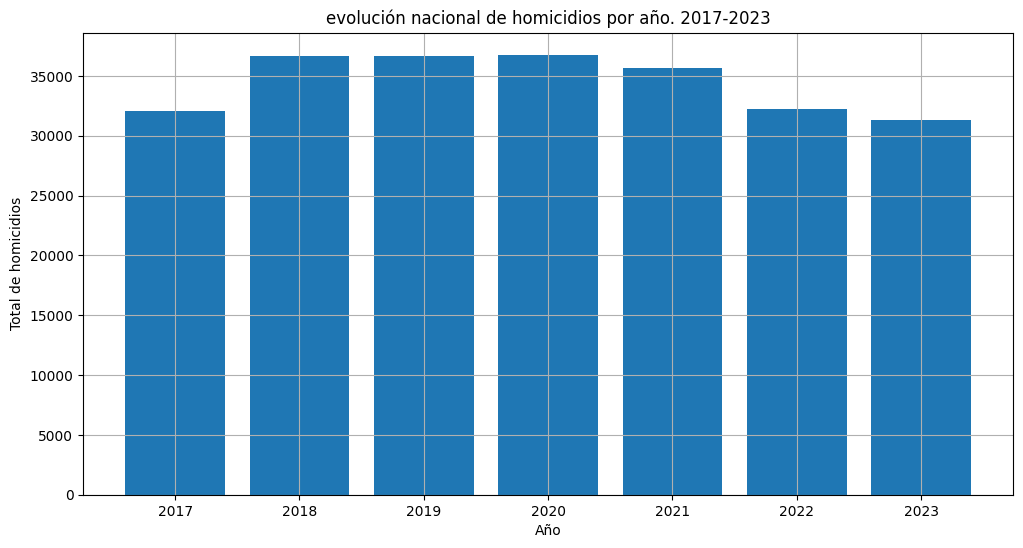

In [114]:
plt.figure(figsize=(12, 6))

plt.bar(range(2017,2024), ev["Total"])
plt.xlabel("Año")
plt.ylabel("Total de homicidios")
plt.title("evolución nacional de homicidios por año. 2017-2023")
plt.xticks()
plt.grid()
plt.show()

  - ¿La tendencia nacional aumenta, disminuye o se mantiene relativamente estable?

- ¿Cuáles son los 5 estados con más homicidios acumulados?


- ¿Qué región concentra el mayor número de homicidios
Noroeste con 73970 homicidios

- ¿Qué región concentra el menor número de homicidios?

Sureste con 28131 homicidios

- ¿Qué conclusiones generales puedes obtener de la gráfica?
